In [ ]:
import pandas as pd, numpy as np
import tensorflow as tf

In [ ]:
df = pd.read_csv('energydata_complete.csv')

In [ ]:
df['date']=pd.to_datetime(df['date'])

In [ ]:
df = df.drop(['Visibility', 'rv1', 'rv2'], axis=1)

In [ ]:
df['Year'] = df['date'].dt.year
df['Month'] = df['date'].dt.month
df['Day'] = df['date'].dt.day
df['Hour'] = df['date'].dt.hour
df['Minute'] = df['date'].dt.minute

In [ ]:
for lag in range(1, 6):
    df[f'lag_{lag}'] = df['Appliances'].shift(lag)

df = df.dropna()

In [ ]:
df = df.sort_values('date')

train_size = int(len(df) * 0.8)

train = df.iloc[:train_size]
test = df.iloc[train_size:]

X_train = train.drop(['date', 'Appliances'], axis=1)
y_train = train['Appliances']

X_test = test.drop(['date', 'Appliances'], axis=1)
y_test = test['Appliances']

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

y_scaler = MinMaxScaler()

y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1,1))
y_test_scaled = y_scaler.transform(y_test.values.reshape(-1,1))

In [ ]:
def create_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(seq_len, len(X)):
        Xs.append(X[i-seq_len:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

seq_len = 15  # increased from 10

X_seq, y_seq = create_sequences(X_train, y_train_scaled, seq_len)
X_test_seq, y_test_seq = create_sequences(X_test, y_test_scaled, seq_len)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization

model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(X_seq.shape[1], X_seq.shape[2])),
    BatchNormalization(),
    Dropout(0.3),

    LSTM(64, return_sequences=False),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='mae',
    metrics=['mae']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(patience=10, restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-5
)

history = model.fit(
    X_seq, y_seq,
    validation_data=(X_test_seq, y_test_seq),
    epochs=100,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 22s 70ms/step - loss: 0.3247 - mae: 0.3247 - val_loss: 0.0877 - val_mae: 0.0877 - learning_rate: 5.0000e-04
Epoch 2/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 14s 55ms/step - loss: 0.1683 - mae: 0.1683 - val_loss: 0.0709 - val_mae: 0.0709 - learning_rate: 5.0000e-04
Epoch 3/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 14s 55ms/step - loss: 0.1042 - mae: 0.1042 - val_loss: 0.0471 - val_mae: 0.0471 - learning_rate: 5.0000e-04
Epoch 4/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 14s 58ms/step - loss: 0.0707 - mae: 0.0707 - val_loss: 0.0344 - val_mae: 0.0344 - learning_rate: 5.0000e-04
Epoch 5/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 14s 57ms/step - loss: 0.0549 - mae: 0.0549 - val_loss: 0.0329 - val_mae: 0.0329 - learning_rate: 5.0000e-04
Epoch 6/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 22s 62ms/step - loss: 0.0493 - mae: 0.0493 - val_loss: 0.0327 - val_mae: 0.0327 - learning_rate: 5.0000e-04
Epoch 7/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 14s 55ms/step - loss: 0.0476 - mae: 0.0476 - val_loss: 0.0329 - v

In [ ]:
y_pred_scaled = model.predict(X_test_seq)

y_pred = y_scaler.inverse_transform(y_pred_scaled)
y_test_actual = y_scaler.inverse_transform(y_test_seq)

from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test_actual, y_pred)

print("Optimized LSTM MAE:", mae)

123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step
Optimized LSTM MAE: 29.87223403977244


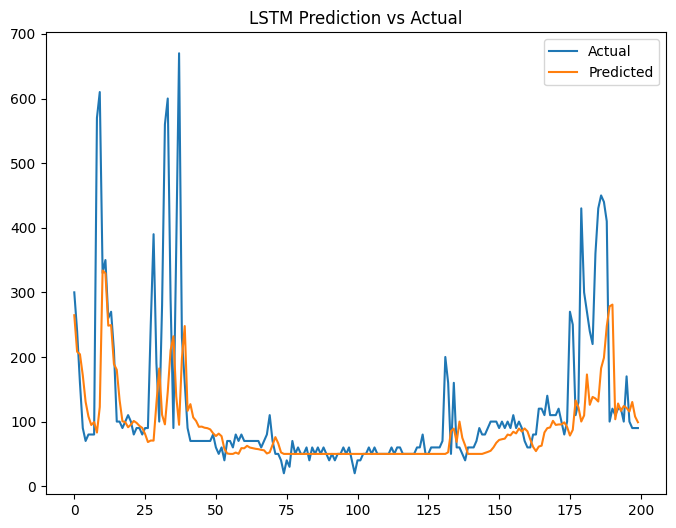

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.plot(y_test_actual[:200], label='Actual')
plt.plot(y_pred[:200], label='Predicted')
plt.legend()
plt.title("LSTM Prediction vs Actual")
plt.show()